In [1]:
!pip install tensorflow-gpu

  Using cached tensorflow-gpu-2.12.0.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [50 lines of output]
  Traceback (most recent call last):
    File "C:\Users\LENOVO\AppData\Local\Temp\pip-build-env-x7ucwpm4\overlay\Lib\site-packages\setuptools\_vendor\packaging\requirements.py", line 36, in __init__
      parsed = _parse_requirement(requirement_string)
    File "C:\Users\LENOVO\AppData\Local\Temp\pip-build-env-x7ucwpm4\overlay\Lib\site-packages\setuptools\_vendor\packaging\_parser.py", line 62, in parse_requirement
      return _parse_requirement(Tokenizer(source, rules=DEFAULT_RULES))
    File "C:\Users\LENOVO\AppData\Local\Temp\pip-build-env-x7ucwpm4\overlay\Lib\site-packages\setuptools\_vendor\packaging\_parser.py", line 80, in _parse_requirement
      url, specifier, marker = _parse_requirement_details(tokenizer)
    File "C:\Users\LENOVO\AppData\Local\Temp\pip-build-env-x7ucwpm4\overlay\Lib\site-packages\setuptools\_vendor\packaging\_par

In [2]:
import tensorflow as tf
print(tf.__version__)

C:\Users\LENOVO\anaconda3\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.9) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
C:\Users\LENOVO\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


2.12.0


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('Churn_Modelling.csv')

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
# Divide the dataset  into independent into dependent features
x = df.iloc[:,3:13]
y = df.iloc[:,13]

In [7]:
x

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77
9997,709,France,Female,36,7,0.00,1,0,1,42085.58
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52


In [8]:
x.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [9]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [10]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [11]:
# Feature Engineering 
geography = pd.get_dummies(x['Geography'],drop_first = True)
gender =  pd.get_dummies(x['Gender'],drop_first = True)

In [12]:
#concatenate these variables  with dataframe
x = x.drop(['Geography','Gender'],axis = 1)

In [13]:
x.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [14]:
x = pd.concat([x,geography,gender],axis = 1)

In [15]:
x.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [16]:
# Splittimg the dataset into traning set and testing set
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.2,random_state=0)

In [17]:
# Feature Scaling
from sklearn.preprocessing  import StandardScaler
sc = StandardScaler()
x_train= sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [18]:
x_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [19]:
x_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [20]:
x_train.shape

(8000, 11)

In [21]:
x_test.shape

(2000, 11)

In [22]:
# Now lets create a ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import LeakyReLU, PReLU, ELU, ReLU


In [49]:
# lets inilizalze the ann
classifier = Sequential()


In [50]:
# Adding the input layer
classifier.add(Dense(units = 11,activation = 'relu'))

In [51]:
# adding the first hidden layer
classifier.add(Dense(units = 7,activation = 'relu'))
classifier.add(Dropout(0.2))

In [52]:
# Adding the second hidden layer
classifier.add(Dense(units = 6,activation = 'relu'))
classifier.add(Dropout(0.3))

In [53]:
# Adding the output layer
classifier.add(Dense(1,activation = 'sigmoid'))

In [54]:
classifier.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [55]:
import  tensorflow as tf
opt = tensorflow.keras.optimizers.Adam(learning_rate = 0.01)

In [56]:
import tensorflow as tf

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=5,
    verbose=1,
    mode="auto",
    restore_best_weights=True
)


In [57]:
model_history = classifier .fit(x_train,y_train,validation_split = 0.33, batch_size = 10, epochs= 10)

Epoch 1/10
536/536 [==============================] - 3s 3ms/step - loss: 0.5445 - accuracy: 0.7578 - val_loss: 0.4611 - val_accuracy: 0.7955
Epoch 2/10
536/536 [==============================] - 1s 3ms/step - loss: 0.4798 - accuracy: 0.7987 - val_loss: 0.4479 - val_accuracy: 0.7986
Epoch 3/10
536/536 [==============================] - 1s 3ms/step - loss: 0.4586 - accuracy: 0.8037 - val_loss: 0.4348 - val_accuracy: 0.8031
Epoch 4/10
536/536 [==============================] - 1s 2ms/step - loss: 0.4493 - accuracy: 0.8099 - val_loss: 0.4188 - val_accuracy: 0.8095
Epoch 5/10
536/536 [==============================] - 1s 3ms/step - loss: 0.4368 - accuracy: 0.8194 - val_loss: 0.4033 - val_accuracy: 0.8186
Epoch 6/10
536/536 [==============================] - 1s 3ms/step - loss: 0.4210 - accuracy: 0.8263 - val_loss: 0.3930 - val_accuracy: 0.8323
Epoch 7/10
536/536 [==============================] - 1s 2ms/step - loss: 0.4150 - accuracy: 0.8280 - val_loss: 0.3908 - val_accuracy: 0.8254
Epoch 

In [58]:
model_history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

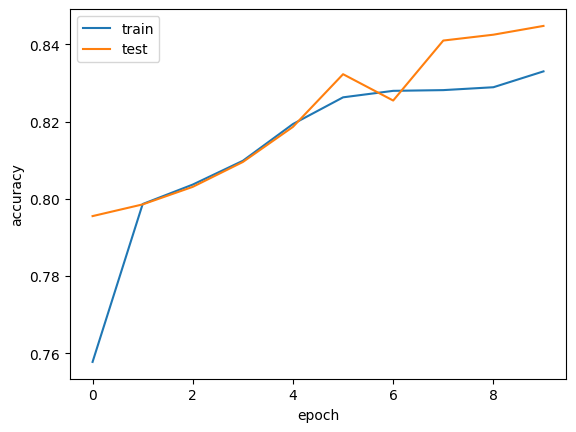

In [59]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()


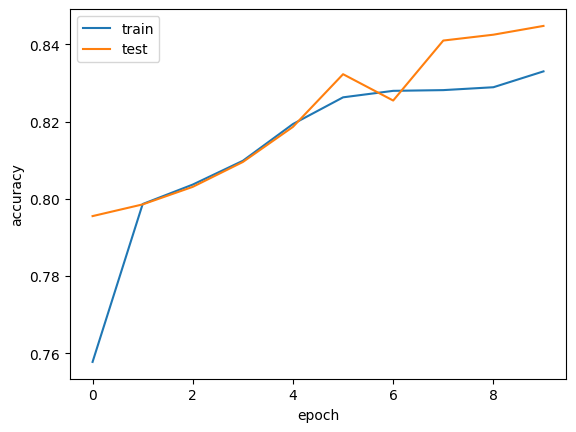

In [60]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()


In [61]:
y_pred = classifier.predict(x_test)
y_pred = (y_pred >0.5)

63/63 [==============================] - 0s 1ms/step


In [62]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred,y_test)
score

0.8535

In [63]:
classifier.get_weights()

[array([[-0.18797988, -0.23828658, -0.21998788, -0.09483541,  0.305512  ,
          0.17607272,  0.05884555,  0.24481624,  0.26361042,  0.22178918,
         -0.0837224 ],
        [ 0.32444263,  0.09175935,  0.06463863, -0.00901723,  0.14520715,
          0.49770212,  0.03530905,  0.24194764, -0.66319484, -1.0267047 ,
         -0.5263088 ],
        [ 0.09936136, -0.18504891, -0.14084424,  0.11194926,  0.41722795,
         -0.12425737, -0.12026819, -0.3860688 , -0.0427765 , -0.03885374,
          0.2322678 ],
        [-0.3929503 , -0.52330196, -0.15247199,  0.23314561, -0.12663677,
         -0.13021596, -0.10011442, -0.20833755, -0.35437572,  0.25733882,
         -0.51366264],
        [-0.16000077, -0.12868692,  0.60519975,  1.0737069 , -0.01497002,
          0.7476409 , -0.9142676 , -0.06135   ,  0.14720158, -0.03939795,
          0.62395805],
        [-0.03008291,  0.15201345, -0.07953165, -0.14705844, -0.30936345,
          0.07843743, -0.19815129, -0.10735113, -0.2276569 ,  0.1041947